<h1><font color = 'red'> <center>GIS Apps in Engineering: Assignment 2</h1>
<h3><font color = 'blue'> <center>Lajuk</h3>

# Vector Analysis with GeoPandas

GeoPandas is the main workhorse for vector analysis in Python. It is useful because it builds on **Pandas** and provides intuitive functions to perform a wide range of vector analysis.  

Vector analysis can be classified into two categories:  
1. Operations on a single vector layer  
2. Operations involving more than one vector layer  

---

## Files Used
1. **Major Roadways in Texas**  
   Download from Census TIGER dataset:  
   [Texas Primary and Secondary Roads (2022)](https://catalog.data.gov/dataset/tiger-line-shapefile-2022-state-texas-primary-and-secondary-roads?utm_source=chatgpt.com)  

   *Note:* MFTCC codes with designations **s1100** and **s1200** denote major highways with limited and unlimited access.  

2. **Texas Counties shapefile**  
   Downloaded earlier from **TxDOT**.  

3. **Well locations (GWDB)**  
   Downloaded from the **Texas Water Development Board**.  

---

## Tasks
1. Bring all data into Python and re-project to **Texas Albers Equal Area (EPSG:3083)**  
2. Compute county areas in **square miles**  
3. Dissolve counties into a single **Texas polygon**  
4. Visualize **roads**, **wells**, and **dissolved Texas** on one map  
5. Draw **buffers**:  
   - 500 m around wells  
   - 100 m around roads  
6. Compute **road lengths in miles**  
7. Group road length per county (overlay counties & roads first), then compute **road density** (length of roads / county area)  
8. Compute **distance from wells to nearest roads** in *Jefferson County*  
9. Count number of wells in each county (**spatial join**)  
10. Use spatial join to count wells **within 1 km of roads** in counties with **>100 wells**  
11. Store all processed data in a single **GeoPackage (.gpkg)**  
12. Create a **100 m buffer** around each major road, erase this polygon from the Texas dissolved map, and compute the **remaining area**.  

**Question:** How much area of Texas is taken up by major roads? (*State your assumptions.*)


In [155]:
import geopandas as gpd
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from shapely.geometry import Point, LineString, Polygon
import os

In [156]:
path = "/Users/washemuzzamanlajuk/Desktop/Fall-2025/GIS/Assignment-2/Data"
os.chdir(path)

In [157]:
#import datasets
ftexas = "County_Boundaries.shp" 
fwells = "TWDB_Groundwater.shp"
froad = "tl_2019_48_prisecroads.shp"
texas = gpd.read_file(ftexas)
wells = gpd.read_file(fwells)
road = gpd.read_file(froad)

In [158]:
crsp = "epsg:3083" # EPSG code for Texas Albers Equal Area projection
texasp = texas.to_crs(crsp) # Reproject counties to EPSG:3083
wellsp = wells.to_crs(crsp) # Reproject wells to EPSG:3083
roadp = road.to_crs(crsp) # Reproject roads to EPSG:3083

Text(0.5, 1.0, 'Major Roads and Wells in Texas')

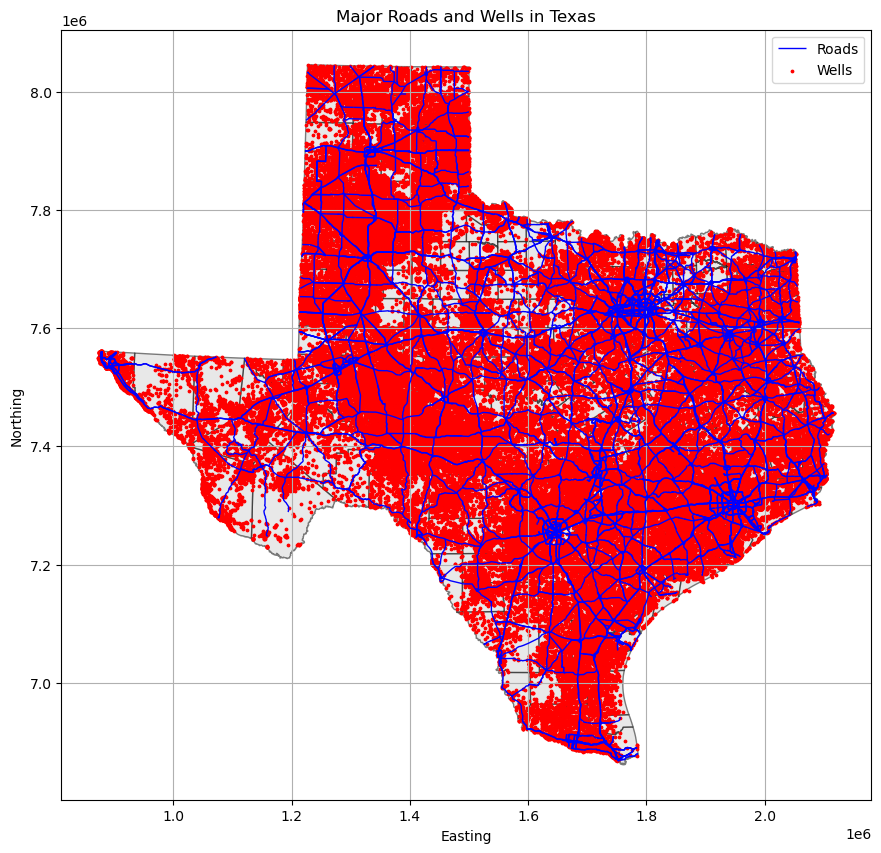

In [159]:
#visualize roads, wells, counties
fig,ax = plt.subplots(figsize=(12,10))
roadp.plot(ax=ax,color ='blue', linewidth =1,label = 'Roads')
texasp.plot(ax=ax,color ='lightgrey', edgecolor = 'black', alpha =0.5)
wellsp.plot(ax=ax,color ='red', markersize=3,label = 'Wells')
plt.grid()
plt.xlabel ('Easting')
plt.ylabel ('Northing')
plt.legend()
plt.title("Major Roads and Wells in Texas")

In [160]:
texasp.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,geometry
0,232,232,48463,232,15,Uvalde,232,15,35,"POLYGON ((1548581.291 7218735.879, 1548468.505..."
1,143,143,48285,143,13,Lavaca,143,13,36,"POLYGON ((1802991.419 7283200.383, 1803004.233..."
2,20,20,48039,20,12,Brazoria,20,12,37,"POLYGON ((1955932.657 7285025.893, 1955942.414..."
3,241,241,48481,241,13,Wharton,241,13,38,"POLYGON ((1869676.725 7285704.18, 1869702.421 ..."
4,163,163,48325,163,15,Medina,163,15,39,"POLYGON ((1557004.141 7228370.693, 1557000.037..."


In [161]:
texasp['AreaSQMI']=texasp.area*(0.000621371**2)

In [162]:
texasp.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,geometry,AreaSQMI
0,232,232,48463,232,15,Uvalde,232,15,35,"POLYGON ((1548581.291 7218735.879, 1548468.505...",1564.693610
1,143,143,48285,143,13,Lavaca,143,13,36,"POLYGON ((1802991.419 7283200.383, 1803004.233...",971.076790
2,20,20,48039,20,12,Brazoria,20,12,37,"POLYGON ((1955932.657 7285025.893, 1955942.414...",1486.249672
3,241,241,48481,241,13,Wharton,241,13,38,"POLYGON ((1869676.725 7285704.18, 1869702.421 ...",1094.348572
4,163,163,48325,163,15,Medina,163,15,39,"POLYGON ((1557004.141 7228370.693, 1557000.037...",1339.619141


In [163]:
area = np.sum(texasp.AreaSQMI)
print(area)

267232.3345392067


<h5> Dissolve the Countys in Texas

In [164]:
texasd = texasp.dissolve() #Requires () as it is a method

<function matplotlib.pyplot.show(close=None, block=None)>

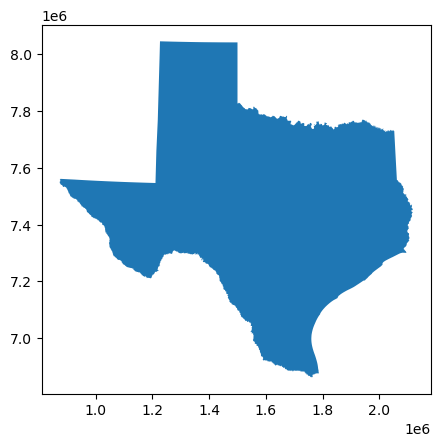

In [165]:
texasd.plot()
plt.show

In [166]:
texasd.head()

,geometry,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,AreaSQMI
0,"POLYGON ((1276002.91 7307500.853, 1276009.411 ...",232,232,48463,232,15,Uvalde,232,15,35,1564.69361


In [167]:
texasd.columns

Index(['geometry', 'CMPTRL_CNT', 'DPS_CNTY_N', 'FIPS_ST_CN', 'TXDOT_CNTY',
       'TXDOT_DIST', 'CNTY_NM', 'CNTY_NBR', 'DIST_NBR', 'GID', 'AreaSQMI'],
      dtype='object')

In [168]:
texasd = texasd.drop(columns=['AreaSQMI'])

In [169]:
texasd.head()

,geometry,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID
0,"POLYGON ((1276002.91 7307500.853, 1276009.411 ...",232,232,48463,232,15,Uvalde,232,15,35


In [170]:
texasd['AreaSQMI']=texasd.area*np.power(0.000621371,2) #Calculate polygon area in square miles and store in new column

In [171]:
texasd.head()

,geometry,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,AreaSQMI
0,"POLYGON ((1276002.91 7307500.853, 1276009.411 ...",232,232,48463,232,15,Uvalde,232,15,35,267232.334434


In [172]:
roadp["LengthMI"] = roadp.length / 1609.34  
# Compute length of each road geometry (GeoSeries.length gives meters in EPSG:3083).  
# Convert meters to miles (1 mile = 1609.34 m). Store in 'length_miles' column.


In [173]:
np.sum(roadp.LengthMI) #Calculate the total length of all road segments (in miles)

np.float64(63284.53742609161)

<h3> Approximate road area in Texas Highways

In [174]:
width = 35 #Roads occupy 75 metersHighways in total for buffer its half
roadsb = roadp.copy()
roadsb['geometry'] = roadsb.geometry.buffer(width) # Apply buffer: expand each road line into a polygon of given width


In [175]:
roadsb.head()

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry,LengthMI
0,1102671600066,S Walton Walker Rmp,M,S1200,"POLYGON ((1791124.277 7623026.222, 1791122.834...",0.220021
1,1102671599582,S Walton Walker Rmp,M,S1200,"POLYGON ((1791074.521 7623041.707, 1791072.581...",0.221517
2,110449721117,West S Lp,M,S1200,"POLYGON ((1668850.606 7566623.114, 1668850.806...",0.624277
3,110449719101,W S Lp,M,S1200,"POLYGON ((1668442.481 7566371.953, 1668588.38 ...",0.347293
4,1106039033336,E S Lp,M,S1200,"POLYGON ((1669761.635 7567180.233, 1669762.734...",1.388960


In [176]:
roadsb['AreaSQMI'] = roadsb.area*np.power(0.0006213712,2)
roadsb.head()

,LINEARID,FULLNAME,RTTYP,MTFCC,geometry,LengthMI,AreaSQMI
0,1102671600066,S Walton Walker Rmp,M,S1200,"POLYGON ((1791124.277 7623026.222, 1791122.834...",0.220021,0.011053
1,1102671599582,S Walton Walker Rmp,M,S1200,"POLYGON ((1791074.521 7623041.707, 1791072.581...",0.221517,0.011118
2,110449721117,West S Lp,M,S1200,"POLYGON ((1668850.606 7566623.114, 1668850.806...",0.624277,0.028637
3,110449719101,W S Lp,M,S1200,"POLYGON ((1668442.481 7566371.953, 1668588.38 ...",0.347293,0.016589
4,1106039033336,E S Lp,M,S1200,"POLYGON ((1669761.635 7567180.233, 1669762.734...",1.388960,0.061897


In [177]:
# Task: Calculate the total land area occupied by all buffered roads (in square miles)
sum(roadsb.AreaSQMI)

2764.9544684026887

<h3>Find the length per County (Spatial Join)

In [178]:
roadscty = gpd.overlay(roadp,texasp,how ='intersection')

In [179]:
roadscty.columns

Index(['LINEARID', 'FULLNAME', 'RTTYP', 'MTFCC', 'LengthMI', 'CMPTRL_CNT',
       'DPS_CNTY_N', 'FIPS_ST_CN', 'TXDOT_CNTY', 'TXDOT_DIST', 'CNTY_NM',
       'CNTY_NBR', 'DIST_NBR', 'GID', 'AreaSQMI', 'geometry'],
      dtype='object')

In [180]:
roadscty.head()

,LINEARID,FULLNAME,RTTYP,MTFCC,LengthMI,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,AreaSQMI,geometry
0,1102671600066,S Walton Walker Rmp,M,S1200,0.220021,57,57,48113,57,18,Dallas,57,18,177,908.412098,"LINESTRING (1791293.798 7623070.326, 1791122.4..."
1,1102671599582,S Walton Walker Rmp,M,S1200,0.221517,57,57,48113,57,18,Dallas,57,18,177,908.412098,"LINESTRING (1791294.231 7623081.564, 1791073.7..."
2,110449721117,West S Lp,M,S1200,0.624277,72,72,48143,73,2,Erath,73,2,149,1087.397818,"LINESTRING (1668852.254 7566582.529, 1668869.5..."
3,110449719101,W S Lp,M,S1200,0.347293,72,72,48143,73,2,Erath,73,2,149,1087.397818,"LINESTRING (1668373.606 7566294.178, 1668459.8..."
4,1106039033336,E S Lp,M,S1200,1.388960,72,72,48143,73,2,Erath,73,2,149,1087.397818,"LINESTRING (1669708.783 7567107.535, 1669779.6..."


In [181]:
roadsctyg = roadscty.groupby('CNTY_NM')['LengthMI'].sum().reset_index()

In [182]:
roadsctyg.head()

,CNTY_NM,LengthMI
0,Anderson,332.252502
1,Andrews,565.223176
2,Angelina,366.664069
3,Aransas,100.591504
4,Archer,322.383693


In [183]:
roadsctyg.sort_values(by='LengthMI',ascending=False)

,CNTY_NM,LengthMI
100,Harris,2861.077799
56,Dallas,2023.649951
219,Tarrant,1775.090326
14,Bexar,1530.845860
69,El Paso,938.480326
...,...,...
31,Camp,55.585111
196,Roberts,53.965543
212,Somervell,53.033072
16,Borden,48.887401


In [184]:
roadsctyg.loc[(roadsctyg)['CNTY_NM']=='Jefferson'] #Select the row(s) for Jefferson County

,CNTY_NM,LengthMI
122,Jefferson,718.498646


In [185]:
len(roadsctyg)

254

In [186]:
type(roadsctyg)

pandas.core.frame.DataFrame

In [187]:
texasp.columns

Index(['CMPTRL_CNT', 'DPS_CNTY_N', 'FIPS_ST_CN', 'TXDOT_CNTY', 'TXDOT_DIST',
       'CNTY_NM', 'CNTY_NBR', 'DIST_NBR', 'GID', 'geometry', 'AreaSQMI'],
      dtype='object')

In [188]:
texasp = texasp.merge(roadsctyg,on='CNTY_NM')

In [189]:
texasp.columns

Index(['CMPTRL_CNT', 'DPS_CNTY_N', 'FIPS_ST_CN', 'TXDOT_CNTY', 'TXDOT_DIST',
       'CNTY_NM', 'CNTY_NBR', 'DIST_NBR', 'GID', 'geometry', 'AreaSQMI',
       'LengthMI'],
      dtype='object')

In [190]:
texasp['RDdensity'] = texasp.LengthMI/texasp.AreaSQMI 

In [191]:
texasp.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,geometry,AreaSQMI,LengthMI,RDdensity
0,232,232,48463,232,15,Uvalde,232,15,35,"POLYGON ((1548581.291 7218735.879, 1548468.505...",1564.693610,216.031422,0.138066
1,143,143,48285,143,13,Lavaca,143,13,36,"POLYGON ((1802991.419 7283200.383, 1803004.233...",971.076790,306.608005,0.315740
2,20,20,48039,20,12,Brazoria,20,12,37,"POLYGON ((1955932.657 7285025.893, 1955942.414...",1486.249672,632.518252,0.425580
3,241,241,48481,241,13,Wharton,241,13,38,"POLYGON ((1869676.725 7285704.18, 1869702.421 ...",1094.348572,307.707605,0.281179
4,163,163,48325,163,15,Medina,163,15,39,"POLYGON ((1557004.141 7228370.693, 1557000.037...",1339.619141,332.321752,0.248072


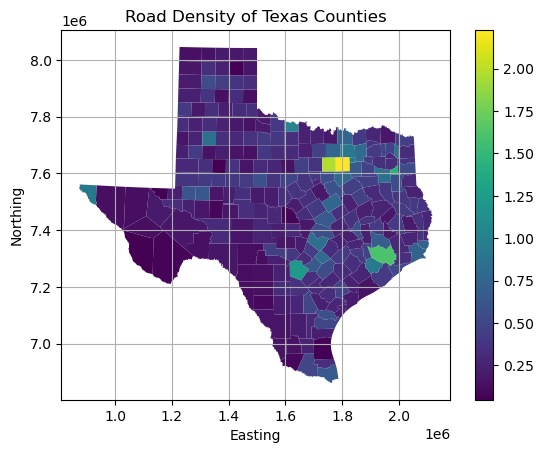

In [192]:
# Plot Road Density of Texas Counties
texasp.plot(column='RDdensity', legend=True)

import matplotlib.pyplot as plt

plt.xlabel('Easting')
plt.ylabel('Northing')
plt.grid()
plt.title('Road Density of Texas Counties')
plt.show()

<h3> Distances to the nearest Highwayfrom a Well in Jefferson County

In [193]:
Jeffersoncty = texasp.loc[texasp["CNTY_NM"]=='Jefferson'] #table joints

In [194]:
Jeffersoncty.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,geometry,AreaSQMI,LengthMI,RDdensity
24,123,123,48245,124,20,Jefferson,124,20,59,"POLYGON ((2058306.075 7355085.315, 2058318.224...",994.077117,718.498646,0.72278


In [195]:
roadp.columns

Index(['LINEARID', 'FULLNAME', 'RTTYP', 'MTFCC', 'geometry', 'LengthMI'], dtype='object')

In [196]:
wellsp.columns

Index(['StateWellN', 'OwnerName', 'PrimaryWat', 'Elevation', 'WellDepth',
       'WaterLevel', 'WaterQuali', 'AquiferCod', 'CoordDDLat', 'CoordDDLon',
       'CountyName', 'WellType', 'geometry'],
      dtype='object')

In [197]:
# Spatial join: assign each well to its county
ctyrds = gpd.sjoin(
    roadp, Jeffersoncty,
    how="inner",        # road info kept only for those roads that intersect
    predicate="intersects" # point inside polygon
)

<Axes: >

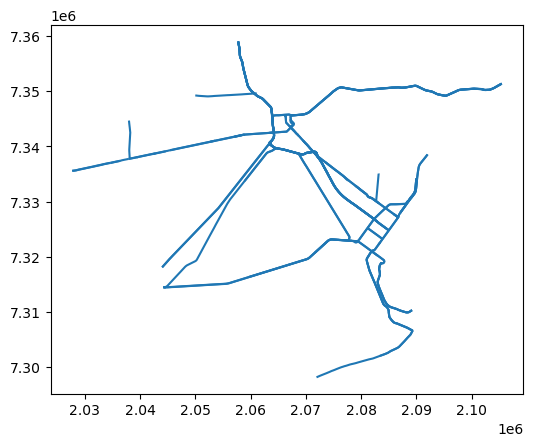

In [198]:
ctyrds.plot()

In [199]:
ctywells = gpd.sjoin(
    wellsp, Jeffersoncty,
    how="inner",        # road info kept only for those roads that intersect
    predicate="within" # point inside polygon
)

<Axes: >

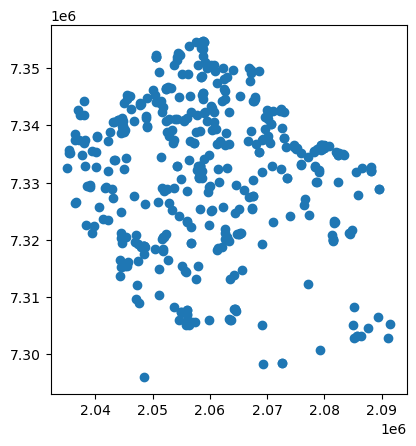

In [200]:
ctywells.plot()

In [201]:
ctyrds.columns

Index(['LINEARID', 'FULLNAME', 'RTTYP', 'MTFCC', 'geometry', 'LengthMI_left',
       'index_right', 'CMPTRL_CNT', 'DPS_CNTY_N', 'FIPS_ST_CN', 'TXDOT_CNTY',
       'TXDOT_DIST', 'CNTY_NM', 'CNTY_NBR', 'DIST_NBR', 'GID', 'AreaSQMI',
       'LengthMI_right', 'RDdensity'],
      dtype='object')

In [202]:
ctyrds = ctyrds.drop(columns =['index_right'])
ctyrds.columns

Index(['LINEARID', 'FULLNAME', 'RTTYP', 'MTFCC', 'geometry', 'LengthMI_left',
       'CMPTRL_CNT', 'DPS_CNTY_N', 'FIPS_ST_CN', 'TXDOT_CNTY', 'TXDOT_DIST',
       'CNTY_NM', 'CNTY_NBR', 'DIST_NBR', 'GID', 'AreaSQMI', 'LengthMI_right',
       'RDdensity'],
      dtype='object')

In [203]:
ctywells.columns

Index(['StateWellN', 'OwnerName', 'PrimaryWat', 'Elevation', 'WellDepth',
       'WaterLevel', 'WaterQuali', 'AquiferCod', 'CoordDDLat', 'CoordDDLon',
       'CountyName', 'WellType', 'geometry', 'index_right', 'CMPTRL_CNT',
       'DPS_CNTY_N', 'FIPS_ST_CN', 'TXDOT_CNTY', 'TXDOT_DIST', 'CNTY_NM',
       'CNTY_NBR', 'DIST_NBR', 'GID', 'AreaSQMI', 'LengthMI', 'RDdensity'],
      dtype='object')

In [204]:
ctywells = ctywells.drop(columns =['index_right', 'CountyName'])
ctywells.columns

Index(['StateWellN', 'OwnerName', 'PrimaryWat', 'Elevation', 'WellDepth',
       'WaterLevel', 'WaterQuali', 'AquiferCod', 'CoordDDLat', 'CoordDDLon',
       'WellType', 'geometry', 'CMPTRL_CNT', 'DPS_CNTY_N', 'FIPS_ST_CN',
       'TXDOT_CNTY', 'TXDOT_DIST', 'CNTY_NM', 'CNTY_NBR', 'DIST_NBR', 'GID',
       'AreaSQMI', 'LengthMI', 'RDdensity'],
      dtype='object')

In [205]:
ctywells.columns

Index(['StateWellN', 'OwnerName', 'PrimaryWat', 'Elevation', 'WellDepth',
       'WaterLevel', 'WaterQuali', 'AquiferCod', 'CoordDDLat', 'CoordDDLon',
       'WellType', 'geometry', 'CMPTRL_CNT', 'DPS_CNTY_N', 'FIPS_ST_CN',
       'TXDOT_CNTY', 'TXDOT_DIST', 'CNTY_NM', 'CNTY_NBR', 'DIST_NBR', 'GID',
       'AreaSQMI', 'LengthMI', 'RDdensity'],
      dtype='object')

In [206]:
#Find the nearest road for each well in Jefferson County
wellrdnear = gpd.sjoin_nearest(
    ctywells, ctyrds,
    how="left",       # keep all wells, attach nearest road
    distance_col="neardist"  # saves distance value
)

In [207]:
wellrdnear.head()

,StateWellN,OwnerName,PrimaryWat,Elevation,WellDepth,WaterLevel,WaterQuali,AquiferCod,CoordDDLat,CoordDDLon,...,TXDOT_CNTY_right,TXDOT_DIST_right,CNTY_NM_right,CNTY_NBR_right,DIST_NBR_right,GID_right,AreaSQMI_right,LengthMI_right,RDdensity_right,neardist
102269,6154901,C. E. Lowry,Domestic,30,21.0,Miscellaneous Measurements,Y,"112CHCTU - Chicot Aquifer, Upper",30.134722,-94.266112,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,108.223940
102270,6154902,Bevil Oaks MUD,Public Supply,28,450.0,TWDB Current Site Visit,Y,"112CHCTL - Chicot Aquifer, Lower",30.159167,-94.271111,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,2733.943829
102271,6154903,Bevil Oaks M.U.D.,Public Supply,26,550.0,None,Y,"112CHCTL - Chicot Aquifer, Lower",30.159445,-94.271111,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,2764.422134
102272,6154904,Marilyann Mills,Stock,27,530.0,TWDB Current Site Visit,N,"112CHCTL - Chicot Aquifer, Lower",30.161667,-94.270278,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,3021.086411
102273,6154905,Bevil Oaks M.U.D. Well #3,Public Supply,26,572.0,Historical,Y,"112CHCTL - Chicot Aquifer, Lower",30.159167,-94.271389,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,2729.515771


In [208]:
# Sort wells by nearest road distance (ascending)
wellrdnear.sort_values(by="neardist", ascending=True)

,StateWellN,OwnerName,PrimaryWat,Elevation,WellDepth,WaterLevel,WaterQuali,AquiferCod,CoordDDLat,CoordDDLon,...,TXDOT_CNTY_right,TXDOT_DIST_right,CNTY_NM_right,CNTY_NBR_right,DIST_NBR_right,GID_right,AreaSQMI_right,LengthMI_right,RDdensity_right,neardist
104429,6414105,Centana Pipeline,Domestic,14,164.0,TWDB Current Site Visit,Y,"112CHCTU - Chicot Aquifer, Upper",29.833889,-94.341944,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,1.498443
104749,6424501,Sea Breeze Inn,Domestic,5,6.0,Miscellaneous Measurements,N,"112CHCTU - Chicot Aquifer, Upper",29.668055,-94.072500,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,7.712040
103942,6407205,Max B. Clark,Industrial,21,142.0,None,Y,"112CHCTU - Chicot Aquifer, Upper",29.985000,-94.201112,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,9.458376
103943,6407206,Max B. Clark,Industrial,21,126.0,None,Y,"112CHCTU - Chicot Aquifer, Upper",29.985000,-94.201112,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,9.458376
103939,6407202,R. H. Hunter,Unused,21,18.0,Miscellaneous Measurements,Y,"112CHCTU - Chicot Aquifer, Upper",29.984722,-94.201389,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,9.904896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103900,6405501,Willis McDermand,Domestic,44,413.0,None,Y,"112CHCTL - Chicot Aquifer, Lower",29.936945,-94.431111,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,10676.526434
104745,6423302,McFadden Ranch,Unused,3,70.0,Miscellaneous Measurements,N,"112CHCTU - Chicot Aquifer, Upper",29.741389,-94.164167,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,10811.548874
104744,6423301,McFadden Trust,Unused,3,82.0,None,Y,"112CHCTU - Chicot Aquifer, Upper",29.740834,-94.159445,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,10984.228953
104746,6423303,McFadden Ranch,Unused,3,93.0,Miscellaneous Measurements,N,"112CHCTU - Chicot Aquifer, Upper",29.739445,-94.161667,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,11080.289389


In [209]:
wellrdnear.head()

,StateWellN,OwnerName,PrimaryWat,Elevation,WellDepth,WaterLevel,WaterQuali,AquiferCod,CoordDDLat,CoordDDLon,...,TXDOT_CNTY_right,TXDOT_DIST_right,CNTY_NM_right,CNTY_NBR_right,DIST_NBR_right,GID_right,AreaSQMI_right,LengthMI_right,RDdensity_right,neardist
102269,6154901,C. E. Lowry,Domestic,30,21.0,Miscellaneous Measurements,Y,"112CHCTU - Chicot Aquifer, Upper",30.134722,-94.266112,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,108.223940
102270,6154902,Bevil Oaks MUD,Public Supply,28,450.0,TWDB Current Site Visit,Y,"112CHCTL - Chicot Aquifer, Lower",30.159167,-94.271111,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,2733.943829
102271,6154903,Bevil Oaks M.U.D.,Public Supply,26,550.0,None,Y,"112CHCTL - Chicot Aquifer, Lower",30.159445,-94.271111,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,2764.422134
102272,6154904,Marilyann Mills,Stock,27,530.0,TWDB Current Site Visit,N,"112CHCTL - Chicot Aquifer, Lower",30.161667,-94.270278,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,3021.086411
102273,6154905,Bevil Oaks M.U.D. Well #3,Public Supply,26,572.0,Historical,Y,"112CHCTL - Chicot Aquifer, Lower",30.159167,-94.271389,...,124,20,Jefferson,124,20,59,994.077117,718.498646,0.72278,2729.515771


<h3> Wells in each county

In [210]:
wellscty = gpd.sjoin(wellsp,texasp, how='inner', predicate='within')

In [211]:
wellscty.columns

Index(['StateWellN', 'OwnerName', 'PrimaryWat', 'Elevation', 'WellDepth',
       'WaterLevel', 'WaterQuali', 'AquiferCod', 'CoordDDLat', 'CoordDDLon',
       'CountyName', 'WellType', 'geometry', 'index_right', 'CMPTRL_CNT',
       'DPS_CNTY_N', 'FIPS_ST_CN', 'TXDOT_CNTY', 'TXDOT_DIST', 'CNTY_NM',
       'CNTY_NBR', 'DIST_NBR', 'GID', 'AreaSQMI', 'LengthMI', 'RDdensity'],
      dtype='object')

In [212]:
wellscount = wellscty.groupby("CNTY_NM").agg(Wellsct=("StateWellN", "count")).reset_index()
wellscount.head()

,CNTY_NM,Wellsct
0,Anderson,502
1,Andrews,287
2,Angelina,385
3,Aransas,269
4,Archer,223


In [213]:
type(wellscount)

pandas.core.frame.DataFrame

In [214]:
texasz = texasp.merge(wellscount, on="CNTY_NM")

<function matplotlib.pyplot.show(close=None, block=None)>

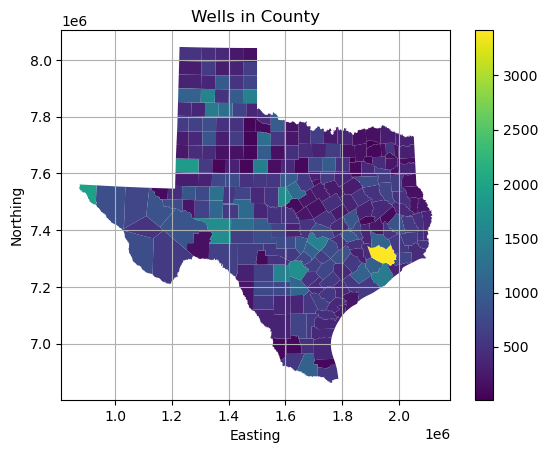

In [215]:
texasz.plot(column="Wellsct", legend=True)
plt.xlabel('Easting')
plt.ylabel('Northing')
plt.grid()
plt.title("Wells in County")
plt.show

In [216]:
wellscount.sort_values(by='Wellsct', ascending=False)

,CNTY_NM,Wellsct
100,Harris,3418
69,El Paso,1940
82,Gaines,1866
14,Bexar,1699
24,Brown,1669
...,...,...
75,Fisher,66
50,Cottle,59
134,King,54
60,Delta,30


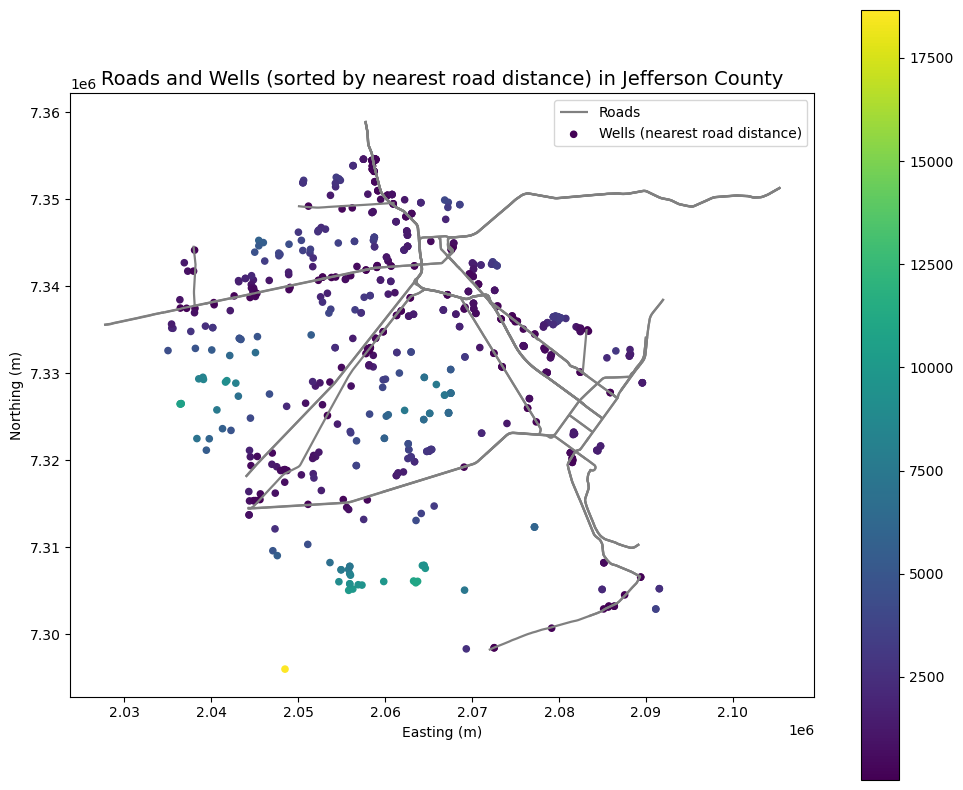

In [217]:
import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot county roads (as lines)
ctyrds.plot(ax=ax, color="gray", linewidth=1.6, label="Roads")

# Plot wells, colored by distance to nearest road
wellrdnear.plot(
    ax=ax,
    column="neardist",      # column created by sjoin_nearest
    cmap="viridis",
    markersize=20,
    legend=True,
    label="Wells (nearest road distance)"
)

# Add labels and legend
ax.set_title("Roads and Wells (sorted by nearest road distance) in Jefferson County", fontsize=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()

plt.show()


<h3> Count wells within 1 km of roads in counties with >100 wells

In [218]:
# Keep only counties with more than 100 wells
cntymorethan100wells = wellscount.loc[wellscount["Wellsct"] > 100, "CNTY_NM"]


In [219]:
# Wells located only in counties with >100 wells
wellsinbigcnty = wellscty[wellscty["CNTY_NM"].isin(cntymorethan100wells)]


In [220]:
# Buffer roads by 1 km
roads_1km = roadp.to_crs(epsg=3083).copy()   # example CRS in meters
roads_1km["geometry"] = roads_1km.geometry.buffer(1000)


In [221]:
wellsinbigcnty = wellsinbigcnty.drop(columns=["index_right"], errors="ignore")
roads_1km = roads_1km.drop(columns=["index_right"], errors="ignore")

In [222]:
# Spatial join: keep wells that intersect 1 km road buffers
wellsnearroads = gpd.sjoin(
    wellsinbigcnty.to_crs(roads_1km.crs),
    roads_1km,
    how="inner",
    predicate="intersects"
)

In [223]:
# Count number of wells within 1 km of roads, by county
wellsnearct = (
    wellsnearroads.groupby("CNTY_NM")
    .agg(WellsNearRoads=("StateWellN", "count"))
    .reset_index()
)

In [224]:
wellsnearct.sort_values(by="WellsNearRoads", ascending=False)

,CNTY_NM,WellsNearRoads
96,Harris,10503
66,El Paso,5997
14,Bexar,4305
204,Tarrant,3671
211,Travis,2242
...,...,...
123,Kenedy,59
142,Loving,29
124,Kent,28
49,Crane,18


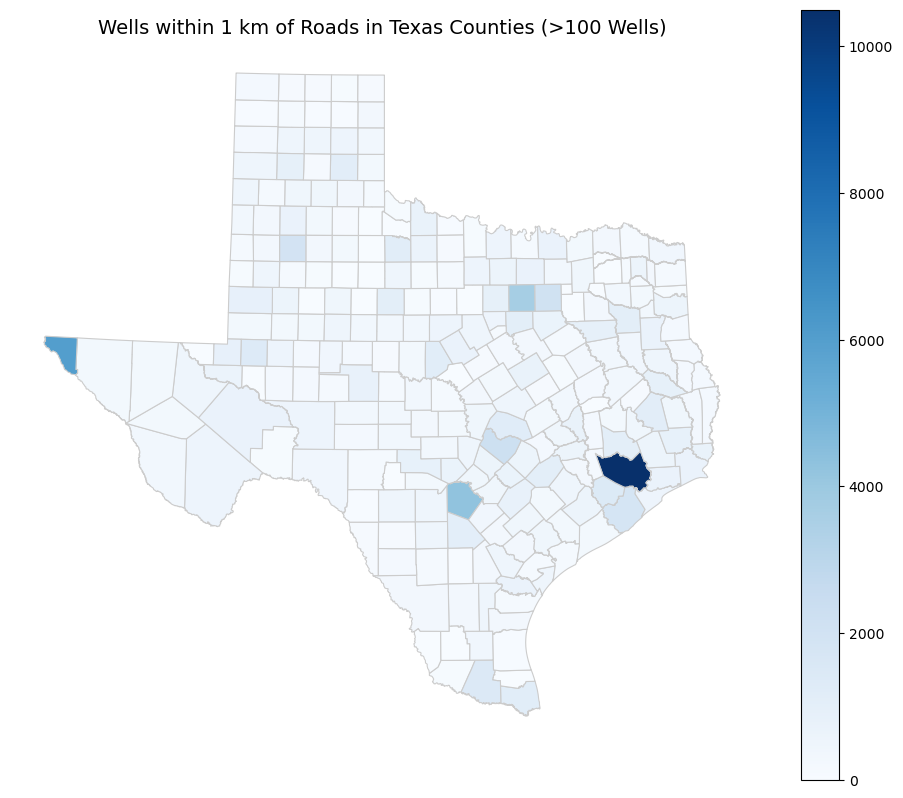

In [225]:
import matplotlib.pyplot as plt

# Merge counts back to county polygons
texasp_plot = texasp.merge(
    wells_near_count,    # table of wells near roads
    on="CNTY_NM",
    how="left"
)

# Fill NaN with 0 (counties with no wells near roads)
texasp_plot["WellsNearRoads"] = texasp_plot["WellsNearRoads"].fillna(0)

# Step 2: Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

texasp_plot.plot(
    column="WellsNearRoads",   # use well counts for coloring
    cmap="Blues",            # color scheme
    linewidth=0.8,
    edgecolor="0.8",
    legend=True,
    ax=ax
)

# Add titles and labels
ax.set_title("Wells within 1 km of Roads in Texas Counties (>100 Wells)", fontsize=14)
ax.axis("off")  # hide axis

plt.show()


In [226]:
wellsnearct.loc[(wellsnearct)['CNTY_NM']=='Jefferson'] #Select the row(s) for Jefferson County

,CNTY_NM,WellsNearRoads
117,Jefferson,731
